# Function to Manually Aggregate from Points to Departements

Arguments:
- Names of Columns to Aggregate
- Name of Polygon Collumn
- Name of Collum that specifies what is the same

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
## Imports

import sys
sys.path.append("..") # Adds the project root to the path

In [3]:
from src.data_exposure import get_exposure
from src.data_hazard import get_haz_dict

In [7]:
exposure = get_exposure(hazard_types=["TC"])

df = exposure.gdf

df

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,insurance,impf_TC,geometry
0,01,Ain,Auvergne-Rhône-Alpes,0.199,5762.4,0.30,1,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,0.532,7361.7,0.32,1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,0.170,7340.1,0.30,1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.025,6925.2,0.18,1,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.017,5548.7,0.18,1,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."
...,...,...,...,...,...,...,...,...
91,91,Essonne,Île-de-France,0.403,1804.4,0.72,1,"POLYGON ((2.58407 48.67715, 2.58038 48.68948, ..."
92,92,Hauts-de-Seine,Île-de-France,NaN,175.6,0.72,1,"POLYGON ((2.33598 48.93158, 2.33491 48.94154, ..."
93,93,Seine-Saint-Denis,Île-de-France,NaN,236.2,0.72,1,"POLYGON ((2.6026 48.92936, 2.6024 48.93532, 2...."
94,94,Val-de-Marne,Île-de-France,0.029,245.0,0.72,1,"POLYGON ((2.61482 48.76112, 2.60645 48.77333, ..."


In [29]:
import climada.util.lines_polys_handler as u_lp
exp_pnt = u_lp.exp_geom_to_pnt(
    exposure,
    res=0.05,
    to_meters=False,
    disagg_met=u_lp.DisaggMethod.FIX,
    disagg_val=None,
)
exp_pnt.gdf.head()

DDEP_C_COD DDEP_L_LIB            DREG_L_LIB  value    area  insurance  \
0 0         01        Ain  Auvergne-Rhône-Alpes  0.199  5762.4        0.3   
  1         01        Ain  Auvergne-Rhône-Alpes  0.199  5762.4        0.3   
  2         01        Ain  Auvergne-Rhône-Alpes  0.199  5762.4        0.3   
  3         01        Ain  Auvergne-Rhône-Alpes  0.199  5762.4        0.3   
  4         01        Ain  Auvergne-Rhône-Alpes  0.199  5762.4        0.3   

     impf_TC                                      geometry_orig  \
0 0        1  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
  1        1  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
  2        1  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
  3        1  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
  4        1  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   

                     geometry  
0 0  POINT (5.63058 45.66149)  
  1  POINT (5.68058 45.66149)  
  2  POINT (5.58058 45.71149)  
  3  POINT (5.63058 45.71149)  
  4  POINT (5.68058 45.71149)

In [30]:
exp_pnt_gdf = exp_pnt.gdf

exp_pnt_gdf

DDEP_C_COD  DDEP_L_LIB            DREG_L_LIB  value    area  insurance  \
0  0          01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4       0.30   
   1          01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4       0.30   
   2          01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4       0.30   
   3          01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4       0.30   
   4          01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4       0.30   
...          ...         ...                   ...    ...     ...        ...   
95 54         95  Val-d'Oise         Île-de-France  0.381  1245.9       0.72   
   55         95  Val-d'Oise         Île-de-France  0.381  1245.9       0.72   
   56         95  Val-d'Oise         Île-de-France  0.381  1245.9       0.72   
   57         95  Val-d'Oise         Île-de-France  0.381  1245.9       0.72   
   58         95  Val-d'Oise         Île-de-France  0.381  1245.9       0.72   

       impf_TC                                      geometry_orig  \
0  0         1  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   1         1  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   2         1  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   3         1  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   4         1  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
...        ...                                                ...   
95 54        1  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   55        1  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   56        1  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   57        1  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   58        1  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   

                       geometry  
0  0   POINT (5.63058 45.66149)  
   1   POINT (5.68058 45.66149)  
   2   POINT (5.58058 45.71149)  
   3   POINT (5.63058 45.71149)  
   4   POINT (5.68058 45.71149)  
...                         ...  
95 54   POINT (2.1088 49.15868)  
   55   POINT (2.1588 49.15868)  
   56   POINT (2.2088 49.15868)  
   57   POINT (2.3088 49.15868)  
   58   POINT (1.7088 49.20868)  

[25740 rows x 9 columns]

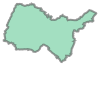

In [31]:
exp_pnt_gdf["geometry_orig"].unique()[0]

In [32]:
exp_pnt.gdf.where(exp_pnt_gdf["geometry_orig"] == exp_pnt_gdf["geometry_orig"].unique()[0])

DDEP_C_COD DDEP_L_LIB            DREG_L_LIB  value    area  insurance  \
0  0          01        Ain  Auvergne-Rhône-Alpes  0.199  5762.4        0.3   
   1          01        Ain  Auvergne-Rhône-Alpes  0.199  5762.4        0.3   
   2          01        Ain  Auvergne-Rhône-Alpes  0.199  5762.4        0.3   
   3          01        Ain  Auvergne-Rhône-Alpes  0.199  5762.4        0.3   
   4          01        Ain  Auvergne-Rhône-Alpes  0.199  5762.4        0.3   
...          ...        ...                   ...    ...     ...        ...   
95 54        NaN        NaN                   NaN    NaN     NaN        NaN   
   55        NaN        NaN                   NaN    NaN     NaN        NaN   
   56        NaN        NaN                   NaN    NaN     NaN        NaN   
   57        NaN        NaN                   NaN    NaN     NaN        NaN   
   58        NaN        NaN                   NaN    NaN     NaN        NaN   

       impf_TC                                      geometry_orig  \
0  0       1.0  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   1       1.0  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   2       1.0  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   3       1.0  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   4       1.0  POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
...        ...                                                ...   
95 54      NaN                                               None   
   55      NaN                                               None   
   56      NaN                                               None   
   57      NaN                                               None   
   58      NaN                                               None   

                       geometry  
0  0   POINT (5.63058 45.66149)  
   1   POINT (5.68058 45.66149)  
   2   POINT (5.58058 45.71149)  
   3   POINT (5.63058 45.71149)  
   4   POINT (5.68058 45.71149)  
...                         ...  
95 54                      None  
   55                      None  
   56                      None  
   57                      None  
   58                      None  

[25740 rows x 9 columns]

In [ ]:
import geopandas as gpd

def agg_to_departement(
    pnt_gdf: gpd.GeoDataFrame,
    value_cols: list,
    poly_col: str = "geometry_orig",
    dep_cols: list = ["DDEP_C_COD", "DDEP_L_LIB", "DREG_L_LIB", "area"],
    agg_func: str | dict = "mean"
):
    """
    Reaggregate point-level data to original department polygons.

    value_cols: columns to aggregate (e.g. value, insurance)
    agg_func: 'sum', 'mean', or dict like {'insurance': 'sum', 'eai': 'mean'}
    """

    # Build aggregation dictionary
    agg_dict = {col: agg_func for col in value_cols}

    # Ensure geometry is preserved (take first polygon per group)
    agg_dict[poly_col] = "first"

    # Group and aggregate
    dep_gdf = (
        pnt_gdf
        .groupby(dep_cols, as_index=False)
        .agg(agg_dict)
        .set_geometry(poly_col)
        .set_crs(pnt_gdf.crs)
    )

    return dep_gdf

In [38]:
agg_to_departement(
    exp_pnt_gdf,
    value_cols=["value", "insurance"]
)

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,area,value,insurance,geometry_orig
0,01,Ain,Auvergne-Rhône-Alpes,5762.4,0.199,0.30,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,7361.7,0.532,0.32,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,7340.1,0.170,0.30,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,6925.2,0.025,0.18,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,5548.7,0.017,0.18,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."
...,...,...,...,...,...,...,...
91,91,Essonne,Île-de-France,1804.4,0.403,0.72,"POLYGON ((2.58407 48.67715, 2.58038 48.68948, ..."
92,92,Hauts-de-Seine,Île-de-France,175.6,NaN,0.72,"POLYGON ((2.33598 48.93158, 2.33491 48.94154, ..."
93,93,Seine-Saint-Denis,Île-de-France,236.2,NaN,0.72,"POLYGON ((2.6026 48.92936, 2.6024 48.93532, 2...."
94,94,Val-de-Marne,Île-de-France,245.0,0.029,0.72,"POLYGON ((2.61482 48.76112, 2.60645 48.77333, ..."


In [39]:
exposure.gdf

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,insurance,impf_TC,geometry
0,01,Ain,Auvergne-Rhône-Alpes,0.199,5762.4,0.30,1,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,0.532,7361.7,0.32,1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,0.170,7340.1,0.30,1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.025,6925.2,0.18,1,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.017,5548.7,0.18,1,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."
...,...,...,...,...,...,...,...,...
91,91,Essonne,Île-de-France,0.403,1804.4,0.72,1,"POLYGON ((2.58407 48.67715, 2.58038 48.68948, ..."
92,92,Hauts-de-Seine,Île-de-France,NaN,175.6,0.72,1,"POLYGON ((2.33598 48.93158, 2.33491 48.94154, ..."
93,93,Seine-Saint-Denis,Île-de-France,NaN,236.2,0.72,1,"POLYGON ((2.6026 48.92936, 2.6024 48.93532, 2...."
94,94,Val-de-Marne,Île-de-France,0.029,245.0,0.72,1,"POLYGON ((2.61482 48.76112, 2.60645 48.77333, ..."
